# House Price Prediction using Linear Regression
This notebook demonstrates a simple machine learning workflow to predict house prices based on various features using a Linear Regression model.

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Generate Synthetic Dataset
np.random.seed(42)
n_samples = 200

# Area in Square Meters (m2) - typically smaller values than SqFt
area_m2 = np.random.normal(200, 50, n_samples)
bathrooms = np.random.randint(1, 4, n_samples)
age = np.random.randint(0, 50, n_samples)

# Price = 1600*area_m2 + 15000*bathrooms - 500*age + noise
price = (1600 * area_m2) + (15000 * bathrooms) - (500 * age) + np.random.normal(0, 15000, n_samples)

data = pd.DataFrame({
    'Area_m2': area_m2,
    # 'Bathrooms': bathrooms,
    # 'Age': age,
    'Price': price
})

display(data.head())

,Area_m2,Price
0,224.835708,380030.195924
1,193.086785,333838.026834
2,232.384427,386757.227207
3,276.151493,456358.197676
4,188.292331,283103.602320


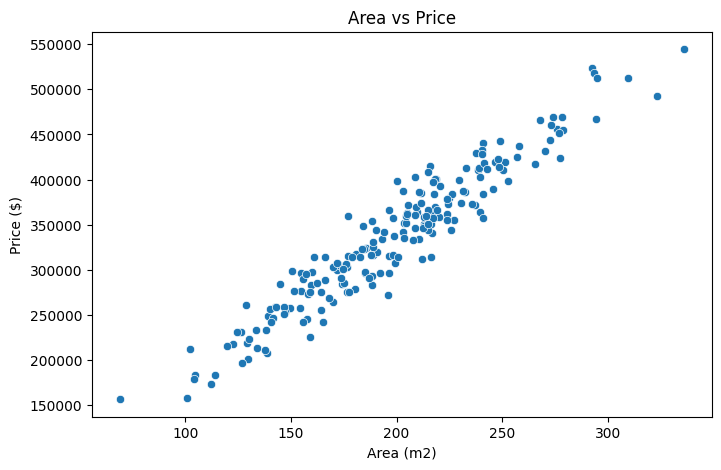

In [90]:
# 2. Visualize Data Relationships
plt.figure(figsize=(8, 5))

sns.scatterplot(data=data, x='Area_m2', y='Price' )
plt.xlabel('Area (m2)')
plt.ylabel('Price ($)')
plt.title('Area vs Price')

plt.show()

In [91]:
# 3. Train Linear Regression Model
X = data[['Area_m2']]
y = data['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# 4. Predictions and Evaluation
y_pred = model.predict(X_test)

print(f'R2 Score: {r2_score(y_test, y_pred):.4f}')
print(f'Mean Absolute Error: ${mean_absolute_error(y_test, y_pred):,.2f}')

R2 Score: 0.9426
Mean Absolute Error: $13,543.06


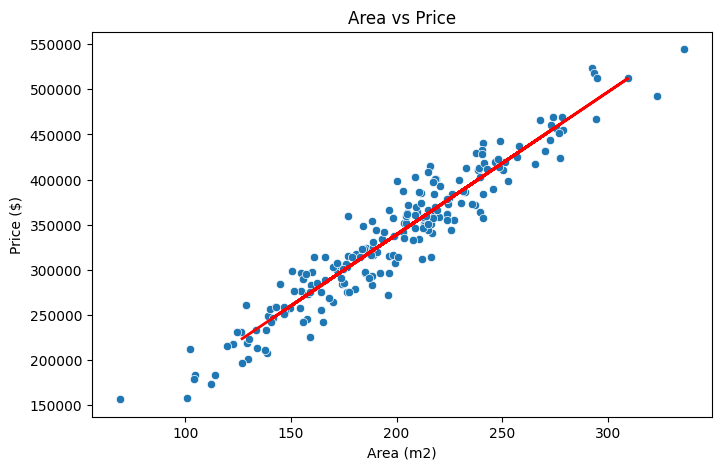

In [92]:

plt.figure(figsize=(8, 5))

sns.scatterplot(data=data, x='Area_m2', y='Price' )
plt.plot(X_test, y_pred, color='red', linewidth=2)
plt.xlabel('Area (m2)')
plt.ylabel('Price ($)')
plt.title('Area vs Price')

plt.show()


### Part 1: Finding the Price Function from Two Points
Imagine a small neighborhood where house prices follow a perfect rule based on area ($m^2$).

*   **House A**: $100\,m^2$ costs $\$200,000$
*   **House B**: $150\,m^2$ costs $\$300,000$

**Goal:** Find the equation $y = mx + b$ where $x$ is area and $y$ is price.

Manual Equation: Price = 1000.0 * Area + 100000.0
This means every extra m2 adds $1000.0 to the price.


Text(0, 10, 'House 2: (200, 300000)')

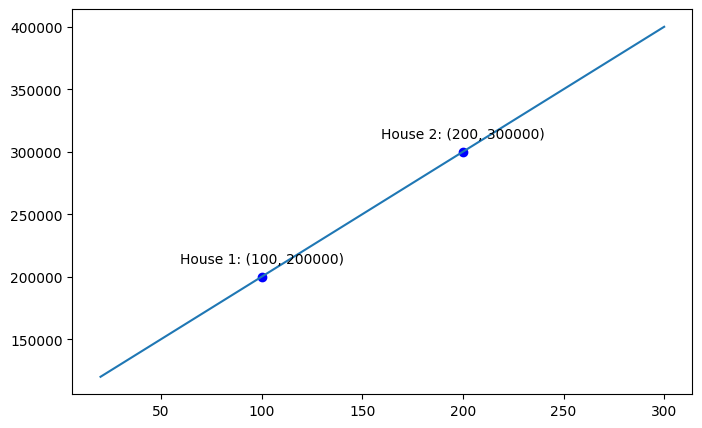

In [93]:
# Points: (100, 200000) and (150, 300000)
x1, y1 = 100, 200000
x2, y2 = 200, 300000

# 1. Calculate Slope (m) = (Change in Price) / (Change in Area)
m = (y2 - y1) / (x2 - x1)

# 2. Calculate Intercept (b) = y - mx
b = y1 - (m * x1)

print(f"Manual Equation: Price = {m} * Area + {b}")
print(f"This means every extra m2 adds ${m} to the price.")

# plot
plt.figure(figsize=(8, 5))
plt.scatter([x1, x2], [y1, y2], color='blue', label='Data Points')

# plot the line
x_line = np.linspace(20, 300, 10)
y_line = m * x_line + b
plt.plot(x_line, y_line)

# show the value at the points
plt.annotate(f'House 1: ({x1}, {y1})', (x1, y1), textcoords="offset points", xytext=(0,10), ha
             ='center')
plt.annotate(f'House 2: ({x2}, {y2})', (x2, y2), textcoords="offset points", xytext=(0,10), ha
             ='center')

### Part 2: Linear Regression with 'Messy' Data
Now, let's look at 5 houses where the prices don't fall perfectly on a line. Linear regression will find the line that 'misses' all points by the smallest amount total.

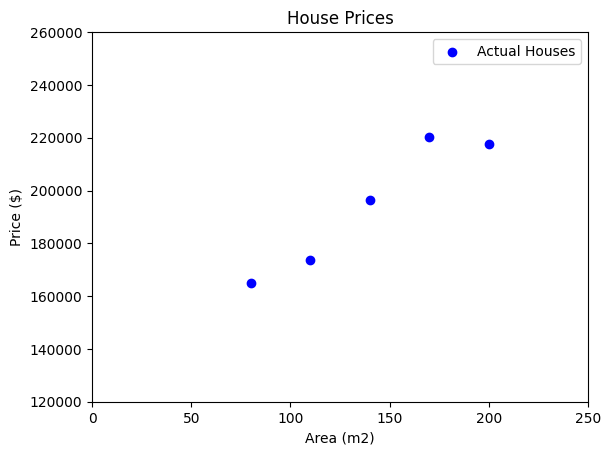

Regression Slope: 506.65
Regression Intercept: 123658.53


In [94]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# set seed for numpy
np.random.seed(42)
# Make data for this
# Price = 500.0 * Area + 120000.0

price_func = lambda area: 500.0 * area + 120000.0


# Simple data for 5 houses
toy_data = pd.DataFrame({
    'Area_m2': [80, 110, 140, 170, 200],
    'Price': [price_func(80), price_func(110), price_func(140), price_func(170), price_func(200)],
})

# add noise
toy_data['Price'] = toy_data['Price'].astype(int) + np.random.normal(0, 10000, len(toy_data)).astype(int)

# Prepare and train the model
X_toy = toy_data[['Area_m2']]
y_toy = toy_data['Price']

toy_model = LinearRegression()
toy_model.fit(X_toy, y_toy)

# Visualization
plt.scatter(toy_data['Area_m2'], toy_data['Price'], color='blue', label='Actual Houses')
# plt.plot(toy_data['Area_m2'], toy_model.predict(X_toy), color='red', label='Regression Line')
X_line = np.linspace(0, 250, 100).reshape(-1, 1)

# set x range from (0, 250)
plt.xlim(0, 250)
plt.ylim(120000, 260000)
# plt.plot(X_line, toy_model.predict(X_line), color='red', label='Regression Line')
plt.xlabel('Area (m2)')
plt.ylabel('Price ($)')
plt.title('House Prices')
plt.legend()
plt.show()

print(f"Regression Slope: {toy_model.coef_[0]:.2f}")
print(f"Regression Intercept: {toy_model.intercept_:.2f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


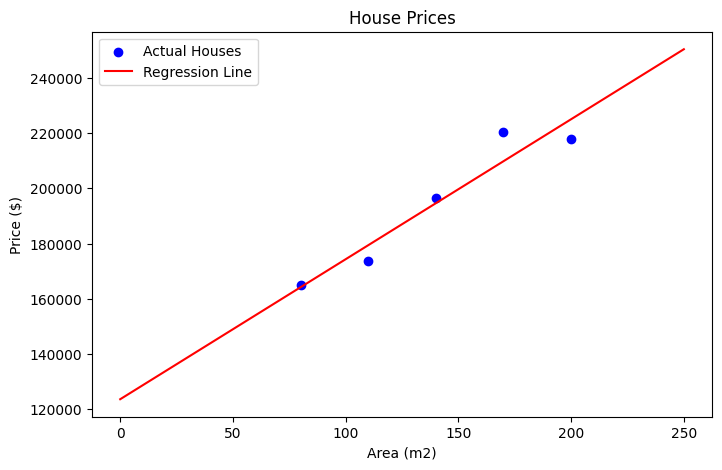

In [95]:
# plot the slope function with the data
plt.figure(figsize=(8, 5))
plt.scatter(toy_data['Area_m2'], toy_data['Price'], color='blue', label='Actual Houses')
plt.plot(X_line, toy_model.predict(X_line), color='red', label='Regression Line')
plt.xlabel('Area (m2)')
plt.ylabel('Price ($)')
plt.title('House Prices')
plt.legend()

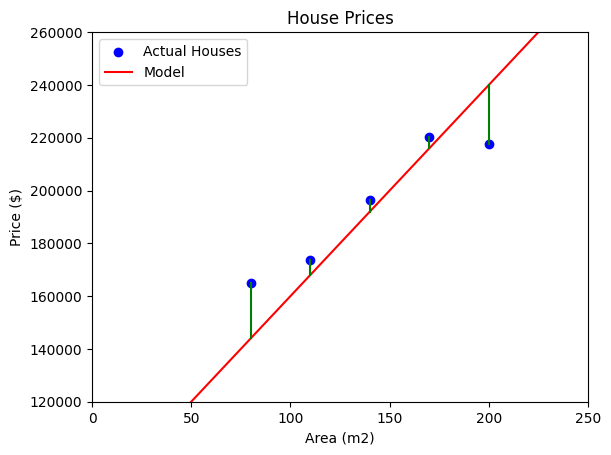

In [96]:
# Visualization
plt.scatter(toy_data['Area_m2'], toy_data['Price'], color='blue', label='Actual Houses')
# plt.plot(toy_data['Area_m2'], toy_model.predict(X_toy), color='red', label='Regression Line')
X_line = np.linspace(0, 250, 100).reshape(-1, 1)
y = 800 * X_line + 80000
plt.plot(X_line, y, color='red', label='Model')

# draw error segments
for i in range(len(toy_data)):
    plt.plot([toy_data['Area_m2'][i], toy_data['Area_m2'][i]], [toy_data['Price'][i], 800 * toy_data['Area_m2'][i] + 80000], color='green')

# set x range from (0, 250)
plt.xlim(0, 250)
plt.ylim(120000, 260000)
# plt.plot(X_line, toy_model.predict(X_line), color='red', label='Regression Line')
plt.xlabel('Area (m2)')
plt.ylabel('Price ($)')
plt.title('House Prices')
plt.legend()
plt.show()


In [97]:
# write loss function

def model(x, a, b):
    return a * x + b

def loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

loss_func = lambda a, b: loss(toy_data['Price'], model(toy_data['Area_m2'], a, b))

# draw loss function 3D


### Update weight based on gradient

In [112]:
import torch
import torch.nn as nn
import torch.optim as optim

def model(x, a, b):
    return a * x + b
def loss(y_true, y_pred):
    return torch.mean((y_true - y_pred) ** 2)

# solution:
# Regression Slope: 506.65
# Regression Intercept: 123658.53

a = torch.tensor(500.0, requires_grad=True)
b = torch.tensor(120000.0, requires_grad=True)

# calculate loss
preds = model(torch.tensor(toy_data['Area_m2'].values), a, b)
loss_value = loss(torch.tensor(toy_data['Price'].values), preds)

# zero grads
a.grad, b.grad = None, None

# derivatives
loss_value.backward()


# update
with torch.no_grad():
    a -= 1e-6 * a.grad
    b -= 1e-6 * b.grad


a, b, a.grad, b.grad

(tensor(501.3091, requires_grad=True),
 tensor(120000.0078, requires_grad=True),
 tensor(-1309152.),
 tensor(-9180.))

In [300]:
# calculate loss
preds = model(torch.tensor(toy_data['Area_m2'].values), a, b)
loss_value = loss(torch.tensor(toy_data['Price'].values), preds)

# zero grads
a.grad, b.grad = None, None

# derivatives
loss_value.backward()


# update
with torch.no_grad():
    a -= 1e-6 * a.grad
    b -= 1 * b.grad


a, b, a.grad, b.grad, loss_value

(tensor(522.2238, requires_grad=True),
 tensor(121357.8359, requires_grad=True),
 tensor(86798.),
 tensor(217.3748),
 tensor(40495848., grad_fn=<MeanBackward0>))

In [100]:
# loss_func(600, 120000)

In [101]:
toy_data

,Area_m2,Price
0,80,164967
1,110,173618
2,140,196476
3,170,220230
4,200,217659


In [102]:
print(f"Regression Slope: {toy_model.coef_[0]:.2f}")
print(f"Regression Intercept: {toy_model.intercept_:.2f}")

Regression Slope: 506.65
Regression Intercept: 123658.53


In [103]:
def L(a, b):
    return (
        107000 * a**2
        + 1400 * a * b
        + 5 * b**2
        - 281545760 * a
        - 1945900 * b
        + 191844832770
    )

# plot 3d of L, with a in range (400, 800) and b in range (8000, 14000)



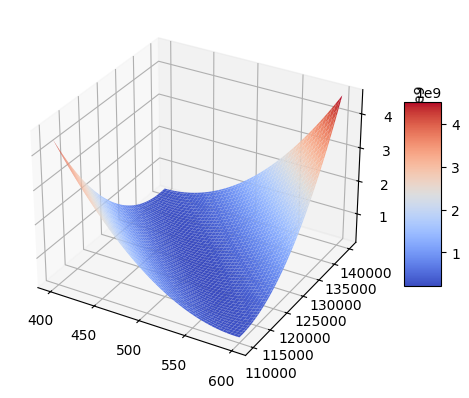

In [104]:
# plot in 3d visualization
from matplotlib import cm
import matplotlib.pyplot as plt
import numpy as np


fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

a = np.linspace(400, 600, 100)[np.newaxis, :]
b = np.linspace(110000, 140000, 100)[:, np.newaxis]


a, b = np.meshgrid(a, b)

# z = [loss_func(a_i, b_i) for a_i, b_i in zip(a.ravel(), b.ravel())]
z = L(a, b)

# Plot the surface.
surf = ax.plot_surface(a, b, np.array(z).reshape(100, 100), cmap=cm.coolwarm,
                       )

# Customize the z axis.
# ax.set_zlim(-1.01, 1.01)
# ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
# ax.zaxis.set_major_formatter('{x:.02f}')

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)


plt.show()

In [105]:
np.array(z).shape

(100, 100)

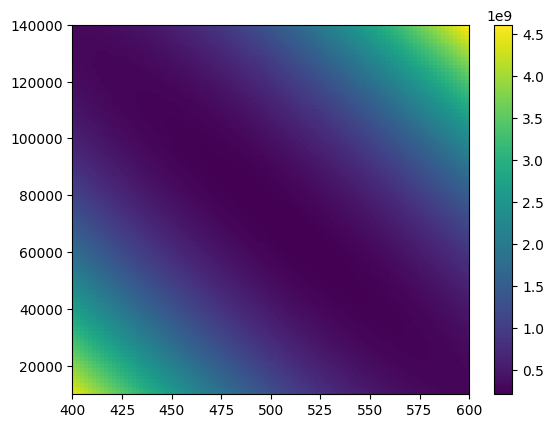

In [106]:
plt.imshow(z, origin='lower', extent=[400, 600, 10000, 140000], aspect='auto',
           cmap='viridis')
plt.colorbar();
